
========== top_k = 3 ==========
Accuracy: 0.3962

Top 10 Features:
                 feature  importance
33  Delivery_Distance_km    0.084327
38        price_per_item    0.084233
32            Driver_Lon    0.082736
30          Customer_Lon    0.082393
31            Driver_Lat    0.082287
29          Customer_Lat    0.081950
27        Restaurant_Lat    0.081660
28        Restaurant_Lon    0.081494
34            order_hour    0.056618
35       order_dayofweek    0.041265

========== top_k = 5 ==========
Accuracy: 0.397

Top 10 Features:
                 feature  importance
35  Delivery_Distance_km    0.082612
40        price_per_item    0.082204
34            Driver_Lon    0.080487
33            Driver_Lat    0.080251
32          Customer_Lon    0.080013
29        Restaurant_Lat    0.079857
30        Restaurant_Lon    0.079411
31          Customer_Lat    0.079366
36            order_hour    0.055672
37       order_dayofweek    0.040372

========== top_k = 6 ==========
Accuracy: 0.3896



,top_k,Accuracy,Top 5 Features
0,3,0.3962,"Delivery_Distance_km, price_per_item, Driver_L..."
1,5,0.3970,"Delivery_Distance_km, price_per_item, Driver_L..."
2,6,0.3896,"Delivery_Distance_km, price_per_item, Driver_L..."
3,10,0.3868,"price_per_item, Delivery_Distance_km, Driver_L..."


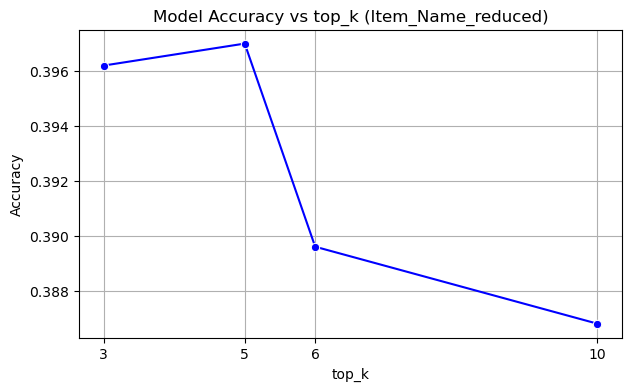

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# =========================================================
# 1. Load Dataset & Define Target
# =========================================================
DATA_PATH = "talabat_enhanced_orders2.csv"
df = pd.read_csv(DATA_PATH)
target_col = "Order_Status"

# =========================================================
# 2. Feature Engineering (Recreating df_fe)
# =========================================================
# Drop leaky columns early
drop_cols_initial = ["Delivery_Time", "Delivery_Duration_Minutes"]
df = df.drop(columns=[c for c in drop_cols_initial if c in df.columns])

df_fe = df.copy()

# Datetime features
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")
df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5, 6]).astype(int)

# Peak hour definition (12-15 and 19-23)
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12, 16)) + list(range(19, 24))).astype(int)

# Price features
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

# =========================================================
# 3. Task: Evaluate different top_k values for Item_Name
# =========================================================
top_k_values = [3, 5, 6, 10]
results = []

for k in top_k_values:
    print(f"\n========== top_k = {k} ==========")
    
    # Prepare data with specific top_k
    df_temp = df_fe.copy()
    
    if "Item_Name" in df.columns:
        top_items = df["Item_Name"].value_counts().head(k).index
        df_temp["Item_Name_reduced"] = np.where(df["Item_Name"].isin(top_items), df["Item_Name"], "Other")
        
    # Define features and target (Make sure we drop original Item_Name and Order_Time)
    drop_cols_temp = [
        "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID", "Total_Price",
        "haversine_rest_to_cust_km", "Order_Time", "Item_Name", "Delivery_Time", "Delivery_Duration_Minutes"
    ]
    drop_cols_temp = [c for c in drop_cols_temp if c in df_temp.columns]
    
    X_temp = df_temp.drop(columns=drop_cols_temp + [target_col])
    y_temp = df_temp[target_col]
    
    # Train-test split
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    
    # Model Pipeline setup
    categorical_cols_t = X_train_t.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols_t = X_train_t.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    
    preprocess_t = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_t),
            ("num", "passthrough", numeric_cols_t),
        ]
    )
    
    rf_t = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    
    model_t = Pipeline(steps=[("preprocess", preprocess_t), ("rf", rf_t)])
    
    # Train and predict
    model_t.fit(X_train_t, y_train_t)
    y_pred_t = model_t.predict(X_test_t)
    acc = accuracy_score(y_test_t, y_pred_t)
    print("Accuracy:", round(acc, 4))
    
    # Extract Feature Importances
    ohe_t = model_t.named_steps["preprocess"].named_transformers_["cat"]
    cat_feature_names_t = ohe_t.get_feature_names_out(categorical_cols_t) if len(categorical_cols_t) > 0 else np.array([])
    all_feature_names_t = np.concatenate([cat_feature_names_t, np.array(numeric_cols_t)])
    
    importances_t = model_t.named_steps["rf"].feature_importances_
    fi_t = pd.DataFrame({"feature": all_feature_names_t, "importance": importances_t}).sort_values("importance", ascending=False)
    
    # Display the Top 10 features for this specific top_k loop
    print("\nTop 10 Features:")
    print(fi_t.head(10))
    
    # Collect results
    top_5_features = ", ".join(fi_t["feature"].head(5).tolist())
    results.append({
        "top_k": k,
        "Accuracy": round(acc, 4),
        "Top 5 Features": top_5_features
    })

# =========================================================
# 4. Final Summary & Visualization
# =========================================================
comparison_df = pd.DataFrame(results)
print("\n========== Summary ==========")
display(comparison_df)

# Plot the accuracies
plt.figure(figsize=(7, 4))
sns.lineplot(data=comparison_df, x="top_k", y="Accuracy", marker="o", color="b")
plt.title("Model Accuracy vs top_k (Item_Name_reduced)")
plt.xlabel("top_k")
plt.ylabel("Accuracy")
plt.xticks(top_k_values)
plt.grid(True)
plt.show()